In [1]:
import sys
from pathlib import Path
import os
from mmengine import Config
import time
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn as nn
from tqdm import tqdm

parent_folder = Path(os.getcwd()).parent  # parent of current folder
sys.path.insert(0, str(parent_folder))


from TorchPropagator import WFS
from PhaseDataset import PhaseDataset
from MaskGeneration import MaskManager
from FramePreprocess import FramePreprocess
from LossFunctions import LogResidualVarianceLoss

In [2]:
class SimpleNet(nn.Module):
    def __init__(self, wfsParams):
        super().__init__()

        Nmodes = wfsParams["Nmodes"]

        self.encoder = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=7, padding=3),
            nn.LeakyReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.LeakyReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=2),
            nn.LeakyReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(256, 512, kernel_size=2, padding=2),
            nn.LeakyReLU(),
            nn.AvgPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            #nn.Dropout(0.2),
        )

        self.outputlayer = nn.Sequential(
            nn.Linear(512, Nmodes),
        )


    def forward(self, x):
        x = self.encoder(x)
        x = self.outputlayer(x)
        return x

In [ ]:
class PWFSNet(nn.Module):
    def __init__(self, n_modes):
        super().__init__()

        self.stem = nn.Sequential(
            # Process each pupil independently
            nn.Conv2d(4, 32, kernel_size=5, padding=2, groups=4),
            nn.GELU(),

            nn.Conv2d(32, 64, kernel_size=5, padding=2, groups=4),
            nn.GELU(),
        )

        self.encoder = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GELU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.GELU(),

            nn.MaxPool2d(2),      # 22 -> 11

            nn.Conv2d(64, 128, 3, padding=1),
            nn.GELU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.GELU(),

            nn.MaxPool2d(2),      # 11 -> 5

            nn.Conv2d(128, 256, 3, padding=1),
            nn.GELU(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, n_modes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.encoder(x)
        return self.head(x)

In [3]:
device = 'cuda' # set to "cpu" if Cuda is not available
    
paramfile = 'wfs_params_exp.py'  # file of experimental parameters


# Config extraction
AtmosParams = Config.fromfile(paramfile)['AtmosParams']
WFSParams = Config.fromfile(paramfile)['WFSParams']
LoopParams = Config.fromfile(paramfile)['LoopParams']
TrainParams = Config.fromfile(paramfile)['TrainParams']

# Dataset creation
dataset = PhaseDataset(WFSParams, AtmosParams, LoopParams, device)
dataset.generateClosedLoop = False

# WFS creation
wfs = WFS(WFSParams, device)

# mask manager creation
maskManager = MaskManager(WFSParams, device, wfs)
maskManager.update_masks()

# Get the reference intensity from the wfs
wfs.BuildReferenceIntensity()

# frame processor creation
framePreprocessor = FramePreprocess(WFSParams, AtmosParams, device, maskManager)
framePreprocessor.ProcessReference(wfs.reference_intensity)

# Phase reconstructor
phaseReconstructor = SimpleNet(WFSParams).to(device = device)


total_params = sum(p.numel() for p in phaseReconstructor.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")


# Optimization parameters (learning rate lr and nb of runs)
lrn = TrainParams['lrn']
num_iterations = 1 # Closed loop iterations

# Number of training and testing run 
TrainRunNb = TrainParams['TrainRunNb']
optimizer_n = torch.optim.AdamW(phaseReconstructor.parameters(), lrn, fused = True)

# Setting the loss
loss_variance = LogResidualVarianceLoss(dataset.pupil)

# Track the loss
loss_tracker = torch.zeros(TrainRunNb // num_iterations, device=device)
loss_tracker_ideal = torch.zeros(TrainRunNb // num_iterations, device=device)


c:\Users\foyarzun\Nextcloud\PhD\Code\Python\WFS_CoConception\venv\lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4384.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Total trainable parameters: 932,082


In [5]:
gain = (torch.rand((dataset.Nphases, 1), device = device) * 0.5 + 0.2)
leak = (torch.rand((dataset.Nphases, 1), device = device) * 0.05 + 0.95)

z_FullRes = dataset.z_FullRes.to(device, dtype=torch.float32).view(-1, dataset.Nmodes).transpose(0, 1)

phaseReconstructor.train()

progressBar = tqdm(range(TrainRunNb // num_iterations))

for u in progressBar:

    phaseGT,pupilGT,modes,photons,ron,r0s,_,_ = dataset[0]
    wfs.SetPhotonsAndRON(photons, ron)

    # Closed-loop correction
    z_estimated = torch.zeros_like(modes)  # Start with zero correction 
    z_buffer = torch.zeros_like(modes)  
    z_output = torch.zeros_like(modes)    
    z_reconstructed = torch.zeros_like(phaseGT)
    z_reconstructed_iter = torch.zeros_like(phaseGT)
    z_reconstructed_ideal = torch.zeros_like(phaseGT)
    z_reconstructed_iter_ideal = torch.zeros_like(phaseGT)
    z_prev = torch.zeros_like(modes)

    total_loss = 0
    ideal_loss = 0

    for i in range(num_iterations):
        # Get new WFS images after applying the correction
        if i > 0:
            phaseGT,pupilGT, modes,_,_,_,_,_ = dataset[i]
        residual_phase = phaseGT - z_reconstructed
        Ze = torch.matmul(residual_phase.flatten(1,2), dataset.invZ)

        # Predict coefficients and update estimate
        z_estimated = z_estimated * leak + gain * z_buffer  # Apply correction with gain
        z_buffer = torch.clone(z_output)

        with torch.no_grad():
            wfs_frames = wfs.Propagator(residual_phase, pupilGT)
            preprocessed_frames = framePreprocessor.ProcessFrame(wfs_frames)
        z_output = phaseReconstructor(preprocessed_frames)
        
        # Convert modes coefficients to full-resolution wavefront
        z_reconstructed = torch.matmul(z_estimated, z_FullRes).view_as(phaseGT)
        z_reconstructed_iter = torch.matmul(z_output, z_FullRes).view_as(phaseGT)
        
        z_reconstructed_ideal = torch.matmul(modes, z_FullRes).view_as(phaseGT)
        z_reconstructed_iter_ideal = torch.matmul(Ze, z_FullRes).view_as(phaseGT)
        
        
        # Compute loss for this iteration
        total_loss += loss_variance((residual_phase - z_reconstructed_iter)) / num_iterations

        # Compute ideal loss for comparison
        with torch.no_grad():
            ideal_loss += loss_variance((residual_phase - z_reconstructed_iter_ideal)) / num_iterations

        
    # **Backpropagation**
    optimizer_n.zero_grad(set_to_none = True)
    
    total_loss.backward()
        
    optimizer_n.step()
    
    # **Track loss and parameters**
    
    loss_tracker[u] = total_loss.detach()
    loss_tracker_ideal[u] = ideal_loss.detach()
    
    if u % (300 // num_iterations) == 1:
        progressBar.set_postfix({'Loss': float(loss_tracker[u-100:u].mean()), 'Loss_ideal': float(ideal_loss)})
        

100%|██████████| 5000/5000 [01:40<00:00, 49.63it/s, Loss=-0.906, Loss_ideal=-1.98]


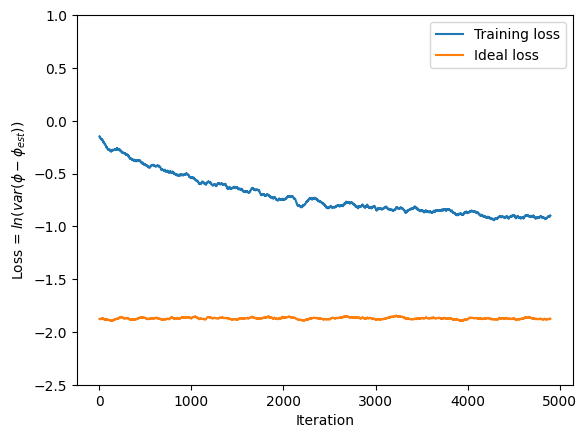

In [11]:
plt.plot(np.convolve(loss_tracker.cpu().detach().numpy(), np.ones(100) / 100, "valid"), label = 'Training loss')
plt.plot(np.convolve(loss_tracker_ideal.cpu().detach().numpy(), np.ones(100) / 100, "valid"), label = 'Ideal loss')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Loss = $ln(var(\phi - \phi_{est}))$')
plt.ylim(-2.5,1)
plt.show()

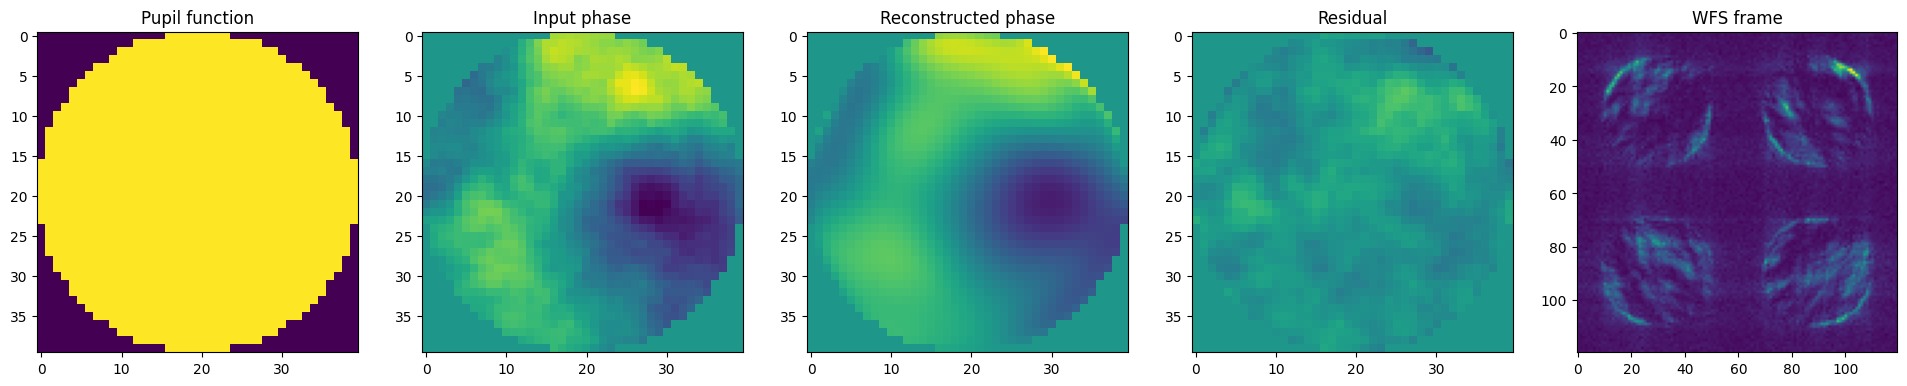

In [12]:
with torch.no_grad():
    gain = 0.3
    dataset.Nphases = 1
    phaseGT,pupilGT,modes,photons,ron,r0s,_,_ = dataset[0]
    wfs.SetPhotonsAndRON(photons, ron)
    wfs_frames = wfs.Propagator(phaseGT, pupilGT)
    preprocessed_frames = framePreprocessor.ProcessFrame(wfs_frames)
    z_output = phaseReconstructor(preprocessed_frames)

    phaseReconstructor.eval()

    fig, ax = plt.subplots(1,5, figsize=(24,18))
    img0 = ax[0].imshow(phaseGT[0].cpu().detach())
    img1 = ax[1].imshow(phaseGT[0].cpu().detach())
    img2 = ax[2].imshow(phaseGT[0].cpu().detach())
    img3 = ax[3].imshow(phaseGT[0].cpu().detach())
    img4 = ax[4].imshow(wfs_frames[0].cpu().detach())


    ax[0].set_title('Pupil function')
    ax[1].set_title('Input phase')
    ax[2].set_title('Reconstructed phase')
    ax[3].set_title('Residual')
    ax[4].set_title('WFS frame')

    a = time.perf_counter()
            
    # Closed-loop correction
    z_estimated = torch.zeros_like(z_output)  # Start with zero correction 
    z_reconstructed = torch.zeros_like(phaseGT)    
    z_buffer = torch.zeros_like(modes)  
    z_output = torch.zeros_like(modes)      

    for i in range(100):
        a = time.perf_counter()
        # Get new WFS images after applying the correction
        if i > 0:
            phaseGT,pupilGT,modes,_,_,_,_,_ = dataset[i]
        # residual_phase = phaseGT - z_reconstructed
        residual_phase = phaseGT - z_reconstructed 
        

        z_estimated = z_estimated * 0.999 + gain * z_buffer  # Apply correction with gain
        z_buffer = torch.clone(z_output)

        wfs_frames = wfs.Propagator(residual_phase, pupilGT)
        preprocessed_frames = framePreprocessor.ProcessFrame(wfs_frames)
        z_output = phaseReconstructor(preprocessed_frames)
        

        z_reconstructed = torch.matmul(z_estimated, z_FullRes).view_as(phaseGT)    

        
        clear_output(wait=True)
        img0.set_data((pupilGT[0] * dataset.pupil).cpu().detach().numpy())
        img0.set_clim(vmin=np.min(img0.get_array()), vmax=np.max(img0.get_array()))
        img1.set_data(phaseGT[0].cpu().detach().numpy())
        img1.set_clim(vmin=np.min(img1.get_array()), vmax=np.max(img1.get_array()))
        img2.set_data(z_reconstructed[0].cpu().detach().numpy())
        img2.set_clim(vmin=np.min(img1.get_array()), vmax=np.max(img1.get_array()))
        img3.set_data(residual_phase[0].cpu().detach().numpy())
        img3.set_clim(vmin=np.min(img1.get_array()), vmax=np.max(img1.get_array()))
        img4.set_data(wfs_frames[0].cpu().detach().numpy())
        img4.set_clim(vmin=np.min(img4.get_array()), vmax=np.max(img4.get_array()))
        display(fig, clear=True)
        
        
        #fig.canvas.draw()
        #fig.canvas.flush_events()
        plt.pause(0.001)
        
        b = time.perf_counter()
        
        # print(f"Loop frequency = {1 / (b - a):.1f} Hz. Residual variance = {Trained_End2EndWFS.GetPhaseVariance(residual_phase[0]).item():.2f} ", end="\r", flush=True)


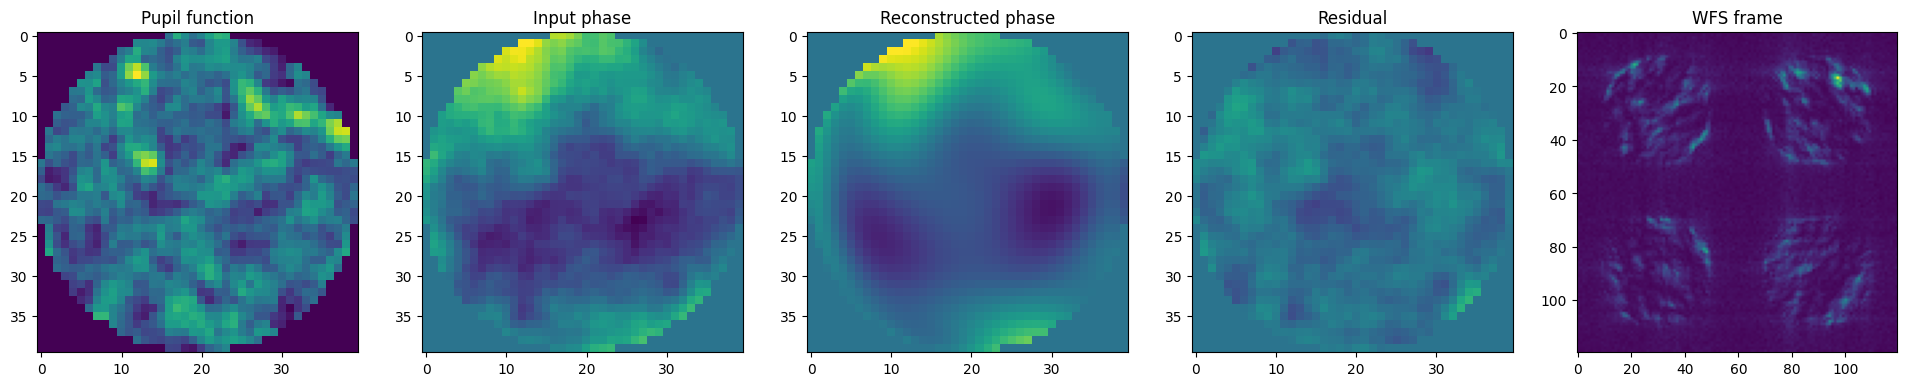

In [13]:
AtmosParams['Scintillation'] = True

# Dataset creation
dataset = PhaseDataset(WFSParams, AtmosParams, LoopParams, device)

with torch.no_grad():
    gain = 0.3
    dataset.Nphases = 1
    phaseGT,pupilGT,modes,photons,ron,r0s,_,_ = dataset[0]
    wfs.SetPhotonsAndRON(photons, ron)
    wfs_frames = wfs.Propagator(phaseGT, pupilGT)
    preprocessed_frames = framePreprocessor.ProcessFrame(wfs_frames)
    z_output = phaseReconstructor(preprocessed_frames)

    phaseReconstructor.eval()

    fig, ax = plt.subplots(1,5, figsize=(24,18))
    img0 = ax[0].imshow(phaseGT[0].cpu().detach())
    img1 = ax[1].imshow(phaseGT[0].cpu().detach())
    img2 = ax[2].imshow(phaseGT[0].cpu().detach())
    img3 = ax[3].imshow(phaseGT[0].cpu().detach())
    img4 = ax[4].imshow(wfs_frames[0].cpu().detach())


    ax[0].set_title('Pupil function')
    ax[1].set_title('Input phase')
    ax[2].set_title('Reconstructed phase')
    ax[3].set_title('Residual')
    ax[4].set_title('WFS frame')

    a = time.perf_counter()
            
    # Closed-loop correction
    z_estimated = torch.zeros_like(z_output)  # Start with zero correction 
    z_reconstructed = torch.zeros_like(phaseGT)    
    z_buffer = torch.zeros_like(modes)  
    z_output = torch.zeros_like(modes)      

    for i in range(100):
        a = time.perf_counter()
        # Get new WFS images after applying the correction
        if i > 0:
            phaseGT,pupilGT,modes,_,_,_,_,_ = dataset[i]
        # residual_phase = phaseGT - z_reconstructed
        residual_phase = phaseGT - z_reconstructed 
        

        z_estimated = z_estimated * 0.999 + gain * z_buffer  # Apply correction with gain
        z_buffer = torch.clone(z_output)

        wfs_frames = wfs.Propagator(residual_phase, pupilGT)
        preprocessed_frames = framePreprocessor.ProcessFrame(wfs_frames)
        z_output = phaseReconstructor(preprocessed_frames)
        

        z_reconstructed = torch.matmul(z_estimated, z_FullRes).view_as(phaseGT)    

        
        clear_output(wait=True)
        img0.set_data((pupilGT[0] * dataset.pupil).cpu().detach().numpy())
        img0.set_clim(vmin=np.min(img0.get_array()), vmax=np.max(img0.get_array()))
        img1.set_data(phaseGT[0].cpu().detach().numpy())
        img1.set_clim(vmin=np.min(img1.get_array()), vmax=np.max(img1.get_array()))
        img2.set_data(z_reconstructed[0].cpu().detach().numpy())
        img2.set_clim(vmin=np.min(img1.get_array()), vmax=np.max(img1.get_array()))
        img3.set_data(residual_phase[0].cpu().detach().numpy())
        img3.set_clim(vmin=np.min(img1.get_array()), vmax=np.max(img1.get_array()))
        img4.set_data(wfs_frames[0].cpu().detach().numpy())
        img4.set_clim(vmin=np.min(img4.get_array()), vmax=np.max(img4.get_array()))
        display(fig, clear=True)
        
        
        #fig.canvas.draw()
        #fig.canvas.flush_events()
        plt.pause(0.001)
        
        b = time.perf_counter()
        
        # print(f"Loop frequency = {1 / (b - a):.1f} Hz. Residual variance = {Trained_End2EndWFS.GetPhaseVariance(residual_phase[0]).item():.2f} ", end="\r", flush=True)
